In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# **GIT2 (VisionEncoderDecoder with ViT + GPT2)**

In [2]:
# ✅ STEP 1: Install libraries
!pip install transformers torch torchvision torchattacks matplotlib --quiet

# ✅ STEP 2: Import necessary modules
import torch
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
from PIL import Image
import requests
import matplotlib.pyplot as plt
import torchvision.transforms as T
from torchattacks import FGSM

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# # ✅ STEP 3: Load the model & tokenizer
# model_name = "nlpconnect/vit-gpt2-image-captioning"
# model = VisionEncoderDecoderModel.from_pretrained(model_name).to("cuda" if torch.cuda.is_available() else "cpu")
# feature_extractor = ViTImageProcessor.from_pretrained(model_name)
# tokenizer = AutoTokenizer.from_pretrained(model_name)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



# Load the model and tokenizer
model = VisionEncoderDecoderModel.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
feature_extractor = ViTImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
tokenizer = AutoTokenizer.from_pretrained("nlpconnect/vit-gpt2-image-captioning")

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.61k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (inte

In [4]:


# ✅ Load image directly from local path (Google Drive)
image_path = "/content/drive/MyDrive/imagecaptioning.jfif"
image = Image.open(image_path).convert("RGB")


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


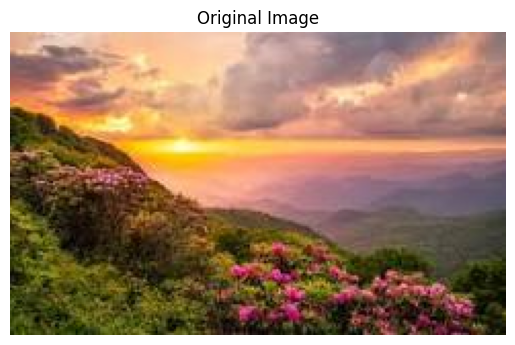

📝 Caption: a view from the top of a mountain


In [5]:
# Preprocess image
pixel_values = feature_extractor(images=image, return_tensors="pt").pixel_values.to(device)

# Generate caption
output_ids = model.generate(pixel_values, max_length=16, num_beams=4)
caption = tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()
# ✅ Show the image
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()
print("📝 Caption:", caption)

# **Attack1**

# Generate Adversarial Image (FGSM)

In [6]:
import torch.nn as nn

# Define FGSM attack
def fgsm_attack(image, epsilon, data_grad):
    # Get the sign of the gradient
    sign_data_grad = data_grad.sign()
    # Add perturbation
    perturbed_image = image + epsilon * sign_data_grad
    # Clamp the values to be valid
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    return perturbed_image

In [7]:
# Preprocess image
image_tensor = feature_extractor(images=image, return_tensors="pt").pixel_values.to(device).requires_grad_()

# Define loss function
outputs = model(image_tensor, labels=tokenizer("a photo", return_tensors="pt").input_ids.to(device))
loss = outputs.loss
# Backprop to get gradients
model.zero_grad()
loss.backward()
image_grad = image_tensor.grad.data



`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


In [8]:
# Generate adversarial image
epsilon = 0.05  # You can try 0.01, 0.1, etc.
adv_image_tensor = fgsm_attack(image_tensor, epsilon, image_grad)

# Generate caption from adversarial image
adv_output_ids = model.generate(adv_image_tensor, max_length=16, num_beams=4)
adv_caption = tokenizer.decode(adv_output_ids[0], skip_special_tokens=True).strip()

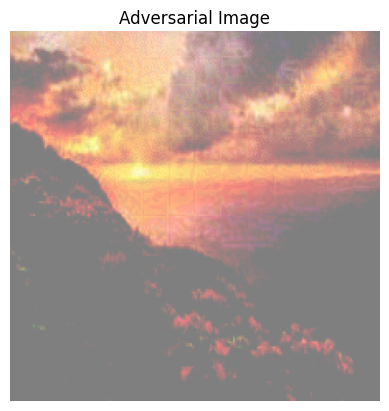

🧪 Adversarial Caption: a sunset view of a mountain with a sky background


In [9]:
# Convert tensor back to image for visualization
unnorm = T.Normalize(mean=[-m/s for m, s in zip(feature_extractor.image_mean, feature_extractor.image_std)],
                     std=[1/s for s in feature_extractor.image_std])
adv_img = unnorm(adv_image_tensor.squeeze()).permute(1, 2, 0).detach().cpu().numpy()
plt.imshow(adv_img)
plt.axis("off")
plt.title("Adversarial Image")
plt.show()
# Show result
print("🧪 Adversarial Caption:", adv_caption)

# **for different epsilon values**

🧪 Adversarial Robustness Evaluation with Visuals:



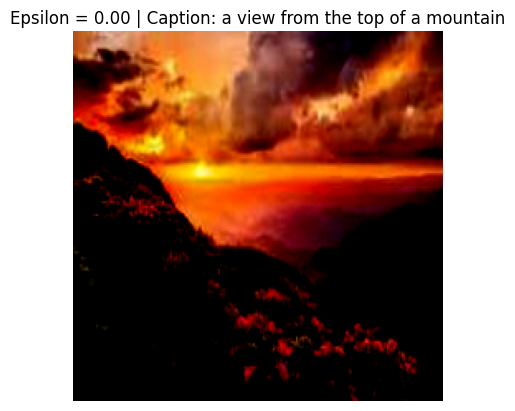

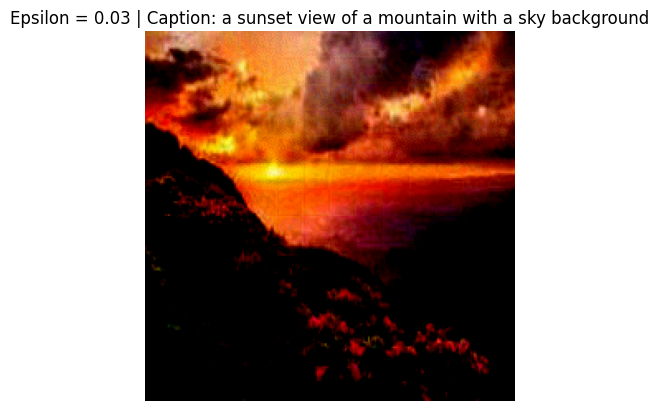

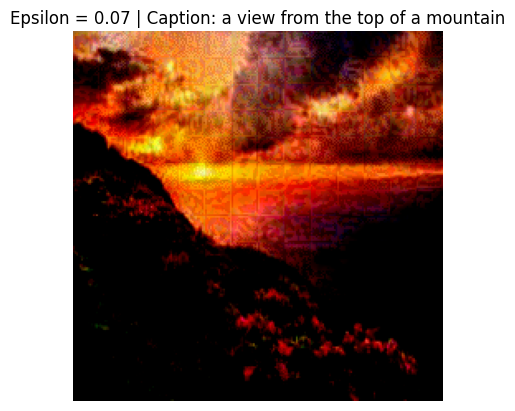

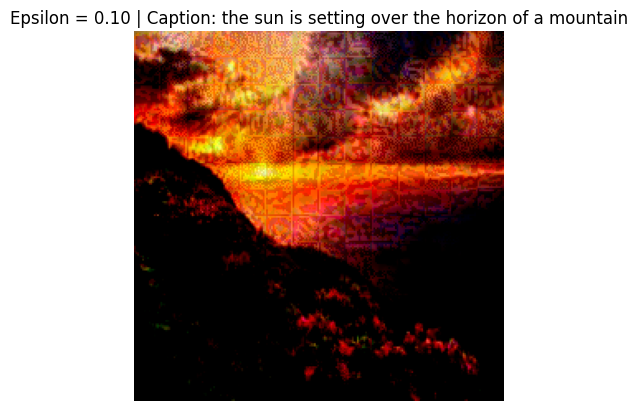

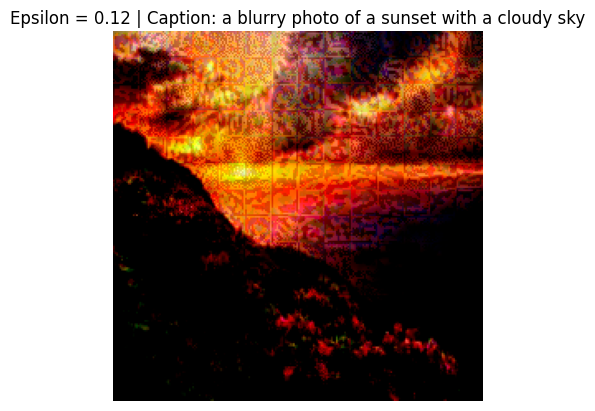

In [10]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image

# FGSM attack function
def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    return perturbed_image

# Store results
results = []

# List of epsilon values to try
epsilons = [0.0, 0.03, 0.07, 0.1, 0.12]

# Preprocess the original image once
original_tensor = feature_extractor(images=image, return_tensors="pt").pixel_values.to(device)

for epsilon in epsilons:
    # Clone and enable gradient
    input_tensor = original_tensor.clone().detach().requires_grad_(True)

    # Forward pass and compute loss
    outputs = model(input_tensor, labels=tokenizer("a photo", return_tensors="pt").input_ids.to(device))
    loss = outputs.loss

    # Backprop to get gradient
    model.zero_grad()
    loss.backward()
    image_grad = input_tensor.grad.data

    # FGSM attack
    adv_tensor = fgsm_attack(input_tensor, epsilon, image_grad)

    # Generate caption from adversarial image
    adv_output_ids = model.generate(adv_tensor, max_length=16, num_beams=4)
    adv_caption = tokenizer.decode(adv_output_ids[0], skip_special_tokens=True).strip()

    # Convert adversarial image tensor to NumPy for display
    adv_img_np = adv_tensor.squeeze().detach().cpu().permute(1, 2, 0).numpy()

    # Store result
    results.append((epsilon, adv_caption, adv_img_np))

# 🖼️ Visualize Results
print("🧪 Adversarial Robustness Evaluation with Visuals:\n")
for eps, cap, img_np in results:
    plt.imshow(img_np)
    plt.title(f"Epsilon = {eps:.2f} | Caption: {cap}")
    plt.axis("off")
    plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# **Attack-2**

# **PGD Attack**

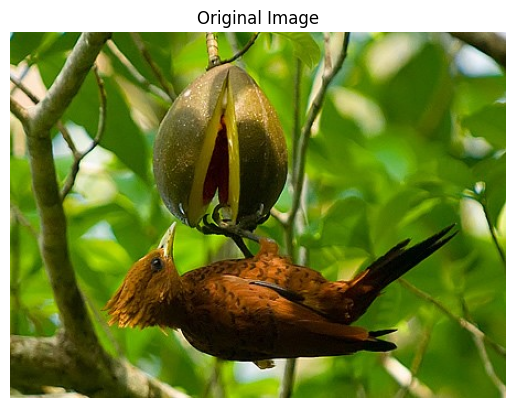

📝 Caption: a bird that is sitting on a branch


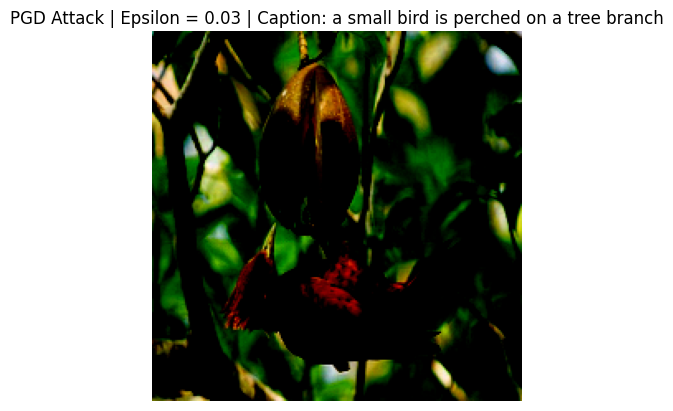

📝 Adversarial Caption: a small bird is perched on a tree branch


In [11]:
import torch.nn as nn
import torch.nn.functional as F

# PGD Attack Function
def pgd_attack(model, images, labels, eps, alpha, iters):
    ori_images = images.clone().detach()
    images = images.clone().detach().requires_grad_(True).to(device)

    for i in range(iters):
        outputs = model(images, labels=labels)
        loss = outputs.loss
        loss.backward()

        adv_images = images + alpha * images.grad.sign()
        eta = torch.clamp(adv_images - ori_images, min=-eps, max=eps)
        images = torch.clamp(ori_images + eta, min=0, max=1).detach().requires_grad_(True)

        model.zero_grad()

    return images

# Set a single epsilon value
epsilon = 0.03
alpha = 0.005  # step size
iterations = 10

# ✅ Load image directly from local path (Google Drive)
image_path2 = "/content/drive/MyDrive/captionimage.jpg"
image2 = Image.open(image_path2).convert("RGB")

#show original image
# Preprocess image
pixel_values2 = feature_extractor(images=image2, return_tensors="pt").pixel_values.to(device)

# Generate caption
output_ids2 = model.generate(pixel_values2, max_length=16, num_beams=4)
caption2 = tokenizer.decode(output_ids2[0], skip_special_tokens=True).strip()
# ✅ Show the image
plt.imshow(image2)
plt.title("Original Image")
plt.axis("off")
plt.show()
print("📝 Caption:", caption2)



# Preprocess image
original_tensor = feature_extractor(images=image2, return_tensors="pt").pixel_values.to(device)
labels = tokenizer("a photo", return_tensors="pt").input_ids.to(device)

# Apply PGD attack
adv_tensor = pgd_attack(model, original_tensor.clone(), labels, epsilon, alpha, iterations)

# Generate caption from adversarial image
adv_output_ids = model.generate(adv_tensor, max_length=16, num_beams=4)
adv_caption = tokenizer.decode(adv_output_ids[0], skip_special_tokens=True).strip()



# Show adversarial image
adv_img_np = adv_tensor.squeeze().detach().cpu().permute(1, 2, 0).numpy()
plt.imshow(adv_img_np)
plt.axis("off")
plt.title(f"PGD Attack | Epsilon = {epsilon} | Caption: {adv_caption}")
plt.show()

print("📝 Adversarial Caption:", adv_caption)


# **for different epsilon values**

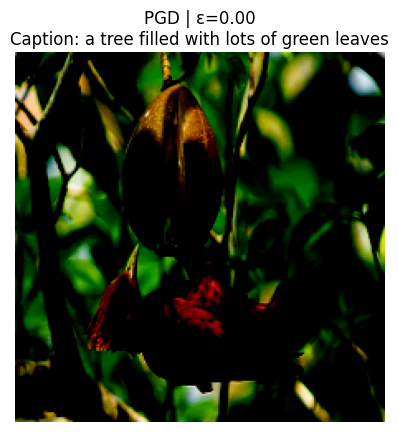

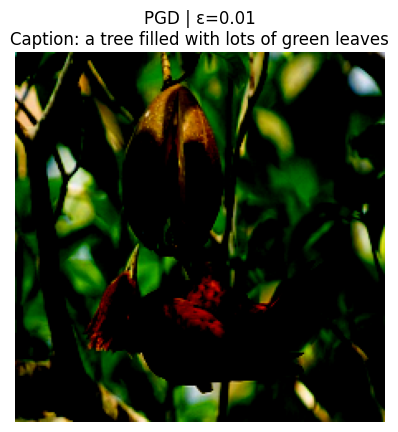

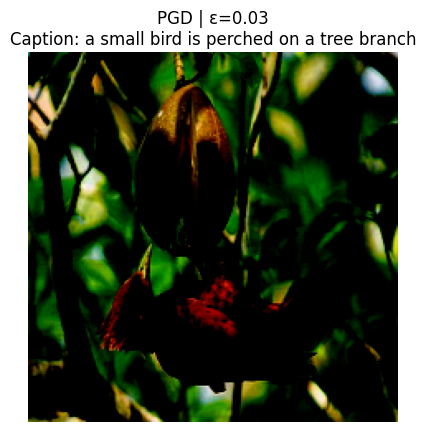

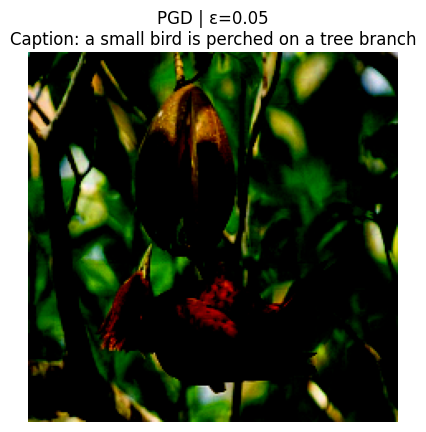

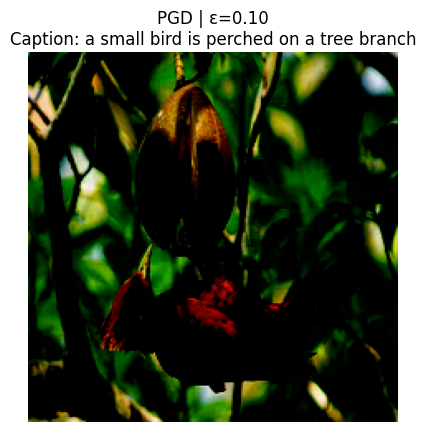

In [12]:
import torch.nn as nn
import torch.nn.functional as F

# PGD Attack Function
def pgd_attack(model, images, labels, eps, alpha, iters):
    ori_images = images.clone().detach()
    images = images.clone().detach().requires_grad_(True).to(device)

    for _ in range(iters):
        outputs = model(images, labels=labels)
        loss = outputs.loss
        loss.backward()

        adv_images = images + alpha * images.grad.sign()
        eta = torch.clamp(adv_images - ori_images, min=-eps, max=eps)
        images = torch.clamp(ori_images + eta, min=0, max=1).detach().requires_grad_(True)
        model.zero_grad()

    return images

# Epsilon values to evaluate
epsilons = [0.0, 0.01, 0.03, 0.05, 0.1]
alpha = 0.005  # step size
iterations = 10

# Preprocess image and label once
original_tensor = feature_extractor(images=image2, return_tensors="pt").pixel_values.to(device)
labels = tokenizer("a photo", return_tensors="pt").input_ids.to(device)

# Loop over epsilons
for eps in epsilons:
    adv_tensor = pgd_attack(model, original_tensor.clone(), labels, eps, alpha, iterations)

    # Generate caption from adversarial image
    adv_output_ids = model.generate(adv_tensor, max_length=16, num_beams=4)
    adv_caption = tokenizer.decode(adv_output_ids[0], skip_special_tokens=True).strip()

    # Show adversarial image
    adv_img_np = adv_tensor.squeeze().detach().cpu().permute(1, 2, 0).numpy()
    plt.imshow(adv_img_np)
    plt.axis("off")
    plt.title(f"PGD | ε={eps:.2f}\nCaption: {adv_caption}")
    plt.show()


# **Attack-3**

# **DeepFool Attack on ViT-GPT2 (Image Captioning)**

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "architectures": [
    "ViTModel"
  ],
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "qkv_bias": true,
  "torch_dtype": "float32",
  "transformers_version": "4.50.3"
}

Config of the decoder: <class 'transformers.models.gpt2.modeling_gpt2.GPT2LMHeadModel'> is overwritten by shared decoder config: GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": true,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "decoder_start_to

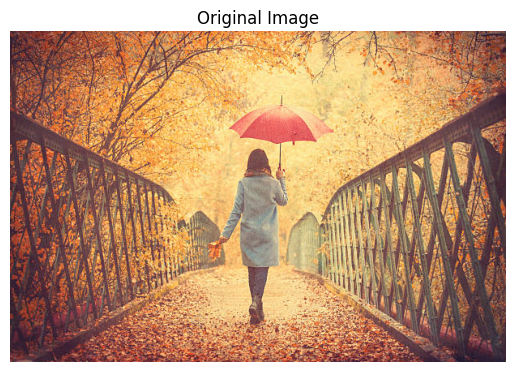

📝 Original Caption: a woman standing in the rain holding an umbrella


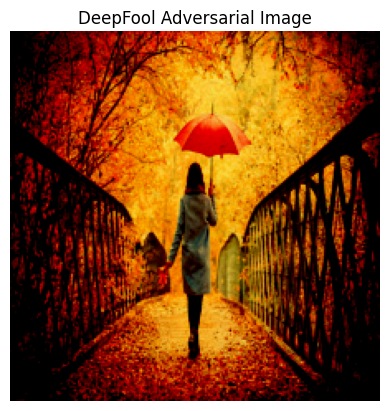

🛡️ Caption After DeepFool: a woman standing in the rain with an umbrella


In [13]:
# Install necessary packages if not already installed
!pip install transformers torch torchvision timm

import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer

# Load ViT-GPT2 model components
model = VisionEncoderDecoderModel.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
feature_extractor = ViTImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
tokenizer = AutoTokenizer.from_pretrained("nlpconnect/vit-gpt2-image-captioning")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Access ViT encoder (not .vision_model, use .encoder for VisionEncoderDecoderModel)
vit_encoder = model.encoder
vit_encoder.eval()

# DeepFool attack implementation
def deepfool_attack(image, model, num_classes=10, overshoot=0.02, max_iter=50):
    image = image.clone().detach().requires_grad_(True).to(device)
    pert_image = image.clone()
    r_tot = torch.zeros_like(image).to(device)
    loop_i = 0
    x = pert_image.clone().detach().requires_grad_(True)

    while loop_i < max_iter:
        outputs = model(x).last_hidden_state.mean(dim=1)
        label = outputs.argmax(dim=1).item()
        output = outputs[0]

        output[label].backward(retain_graph=True)
        grad_orig = x.grad.data.clone()
        x.grad.zero_()

        min_pert = float("inf")
        ri = None

        for k in range(num_classes):
            if k == label:
                continue
            output[k].backward(retain_graph=True)
            grad_k = x.grad.data.clone()
            x.grad.zero_()

            w_k = grad_k - grad_orig
            f_k = (output[k] - output[label]).detach()
            pert_k = torch.abs(f_k) / (w_k.norm() + 1e-8)

            if pert_k < min_pert:
                min_pert = pert_k
                ri = pert_k * w_k / (w_k.norm() + 1e-8)

        r_tot += ri
        pert_image = image + (1 + overshoot) * r_tot
        x = pert_image.clone().detach().requires_grad_(True)

        new_outputs = model(x).last_hidden_state.mean(dim=1)
        new_label = new_outputs.argmax(dim=1).item()
        if new_label != label:
            break
        loop_i += 1

    return torch.clamp(pert_image, 0, 1)

# Load your image
image_path3= "/content/drive/MyDrive/3captionimage.jpg"
image3 = Image.open(image_path3).convert("RGB")

# Show original
plt.imshow(image3)
plt.title("Original Image")
plt.axis("off")
plt.show()

# Get original caption
pixel_values3 = feature_extractor(images=image3, return_tensors="pt").pixel_values.to(device)
output_ids3 = model.generate(pixel_values3, max_length=16, num_beams=4)
caption3 = tokenizer.decode(output_ids3[0], skip_special_tokens=True).strip()
print("📝 Original Caption:", caption3)

# Apply DeepFool to ViT encoder input
perturbed_tensor3 = deepfool_attack(pixel_values3.clone(), vit_encoder)

# Generate caption for adversarial image
output_ids3 = model.generate(perturbed_tensor3, max_length=16, num_beams=4)
perturbed_caption3 = tokenizer.decode(output_ids3[0], skip_special_tokens=True).strip()

# Display adversarial result
plt.imshow(perturbed_tensor3.squeeze().permute(1, 2, 0).detach().cpu().numpy())
plt.title("DeepFool Adversarial Image")
plt.axis("off")
plt.show()
print("🛡️ Caption After DeepFool:", perturbed_caption3)


# **for different epsilon values**

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "architectures": [
    "ViTModel"
  ],
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "qkv_bias": true,
  "torch_dtype": "float32",
  "transformers_version": "4.50.3"
}

Config of the decoder: <class 'transformers.models.gpt2.modeling_gpt2.GPT2LMHeadModel'> is overwritten by shared decoder config: GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": true,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "decoder_start_to

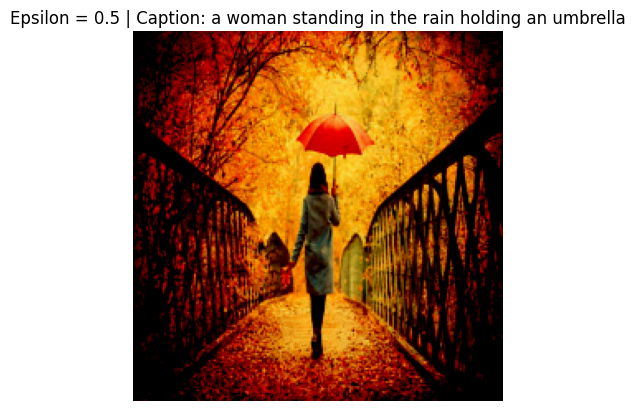

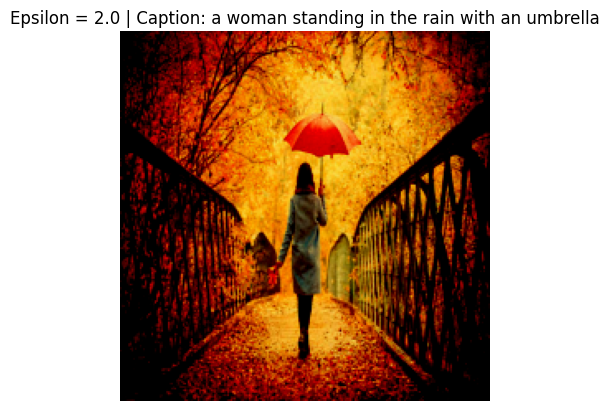

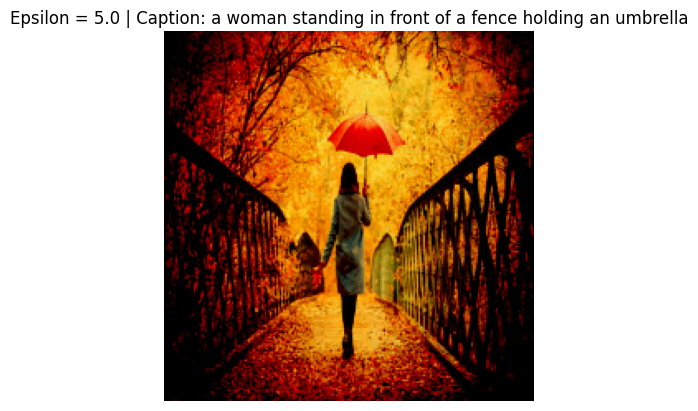

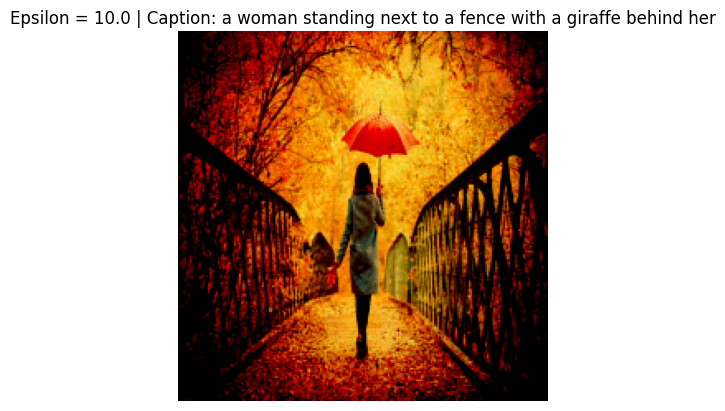

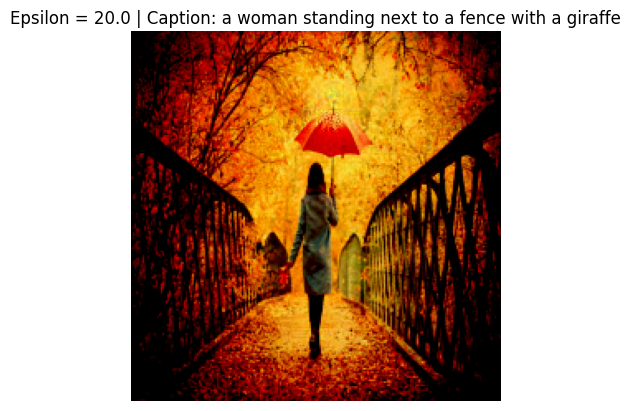

In [14]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer

# Instead of hardcoding "cuda", use the device variable you defined earlier
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the model and move to the correct device
model = VisionEncoderDecoderModel.from_pretrained("nlpconnect/vit-gpt2-image-captioning").to(device)
# ... (rest of your code)



# Load model
#model = VisionEncoderDecoderModel.from_pretrained("nlpconnect/vit-gpt2-image-captioning").to("cuda")
feature_extractor = ViTImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
tokenizer = AutoTokenizer.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
model.eval()
vit_encoder = model.encoder
vit_encoder.eval()

# DeepFool base attack (returns raw perturbation)
def deepfool_perturbation(image, model, num_classes=10, overshoot=0.02, max_iter=50):
    # Use device instead of hardcoding "cuda"
    image = image.clone().detach().requires_grad_(True).to(device)
    pert_image = image.clone()
    # Use device instead of hardcoding "cuda"
    r_tot = torch.zeros_like(image).to(device)
    loop_i = 0
    x = pert_image.clone().detach().requires_grad_(True)

    while loop_i < max_iter:
        outputs = model(x).last_hidden_state.mean(dim=1)
        label = outputs.argmax(dim=1).item()
        output = outputs[0]

        output[label].backward(retain_graph=True)
        grad_orig = x.grad.data.clone()
        x.grad.zero_()

        min_pert = float("inf")
        ri = None

        for k in range(num_classes):
            if k == label:
                continue
            output[k].backward(retain_graph=True)
            grad_k = x.grad.data.clone()
            x.grad.zero_()

            w_k = grad_k - grad_orig
            f_k = (output[k] - output[label]).detach()
            pert_k = torch.abs(f_k) / (w_k.norm() + 1e-8)

            if pert_k < min_pert:
                min_pert = pert_k
                ri = pert_k * w_k / (w_k.norm() + 1e-8)

        r_tot += ri
        x = (image + (1 + overshoot) * r_tot).clone().detach().requires_grad_(True)

        new_outputs = model(x).last_hidden_state.mean(dim=1)
        new_label = new_outputs.argmax(dim=1).item()
        if new_label != label:
            break
        loop_i += 1

    return r_tot.detach()

# Get base perturbation from DeepFool
base_pert = deepfool_perturbation(pixel_values3.clone(), vit_encoder)

# List of epsilon scaling factors
epsilons = [0.5, 2.0 , 5.0, 10.0, 20.0]

# Run for each epsilon
for eps in epsilons:
    adv_tensor3 = torch.clamp(pixel_values3 + eps * base_pert, 0, 1)
    adv_output3 = model.generate(adv_tensor3, max_length=16, num_beams=4)
    adv_caption3 = tokenizer.decode(adv_output3[0], skip_special_tokens=True).strip()

    # Show image + caption
    plt.imshow(adv_tensor3.squeeze().permute(1, 2, 0).detach().cpu().numpy())
    plt.axis("off")
    plt.title(f"Epsilon = {eps} | Caption: {adv_caption3}")
    plt.show()

# **Attack-4**

# **BIM Attack Code for ViT-GPT2 Image Captioning**

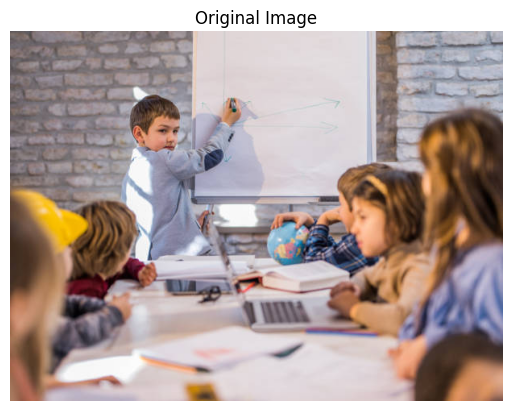

📝 Original Caption: a classroom filled with students and a teacher


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


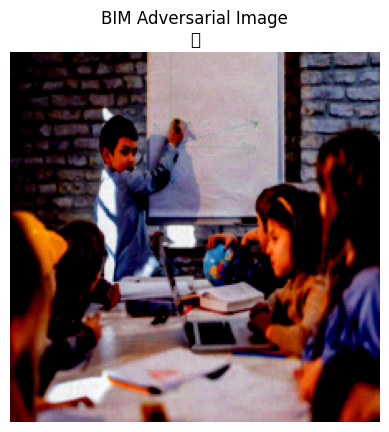

📝 Caption after BIM attack: a large group of people sitting around a table


In [15]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# BIM attack function
def bim_attack(model, image, epsilon=0.03, alpha=0.005, iters=10):
    image = image.clone().detach().to(device)
    ori_image = image.clone().detach()
    image.requires_grad = True

    for i in range(iters):
        outputs = model(image).last_hidden_state.mean(dim=1)
        pred = outputs.argmax(dim=1)

        loss = F.cross_entropy(outputs, pred)
        loss.backward()

        # Gradient sign step
        grad_sign = image.grad.data.sign()
        image = image + alpha * grad_sign
        eta = torch.clamp(image - ori_image, min=-epsilon, max=epsilon)
        image = torch.clamp(ori_image + eta, min=0, max=1).detach_()
        image.requires_grad = True

    return image.detach()

# Load and preprocess the image
image_path4 = "/content/drive/MyDrive/4imagecaption.jpg"
image4 = Image.open(image_path4).convert("RGB")
pixel_values4 = feature_extractor(images=image4, return_tensors="pt").pixel_values.to(device)

# Show original
plt.imshow(image4)
plt.title("Original Image")
plt.axis("off")
plt.show()

# Get original caption
pixel_values4 = feature_extractor(images=image4, return_tensors="pt").pixel_values.to(device)
output_ids4 = model.generate(pixel_values4, max_length=16, num_beams=4)
caption4 = tokenizer.decode(output_ids4[0], skip_special_tokens=True).strip()
print("📝 Original Caption:", caption4)


# Run BIM attack
adv_image4 = bim_attack(vit_encoder, pixel_values4.clone(), epsilon=0.03, alpha=0.005, iters=10)

# Caption the adversarial image
adv_output4 = model.generate(adv_image4, max_length=16, num_beams=4)
adv_caption4 = tokenizer.decode(adv_output4[0], skip_special_tokens=True).strip()

# Show results
plt.imshow(adv_image4.squeeze().permute(1, 2, 0).detach().cpu().numpy())
plt.title(f"BIM Adversarial Image\n📝")
plt.axis("off")
plt.show()

print("📝 Caption after BIM attack:", adv_caption4)


# **for different values of epsilon**

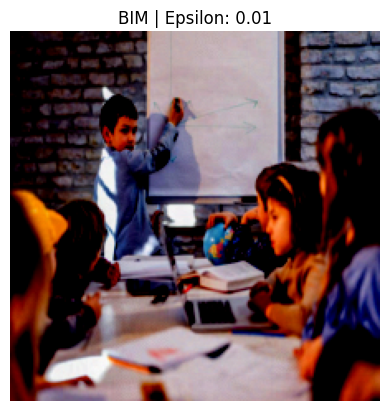

🧪 Epsilon: 0.01 ➤ Caption: a man sitting at a table with a child


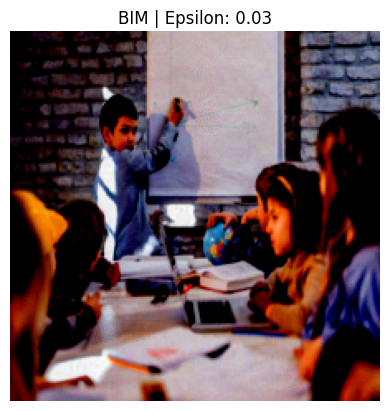

🧪 Epsilon: 0.03 ➤ Caption: a large group of people sitting around a table


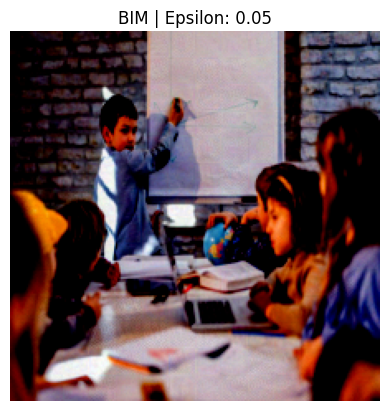

🧪 Epsilon: 0.05 ➤ Caption: people sitting around a table


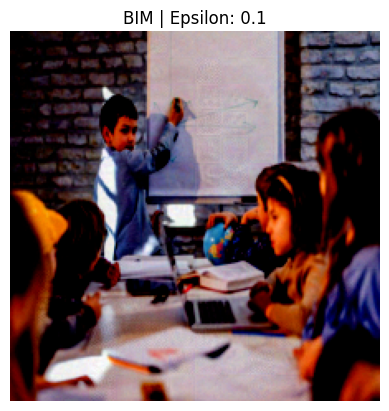

🧪 Epsilon: 0.1 ➤ Caption: a man and a woman sitting at a table with laptops


In [16]:
def bim_attack(model, image, epsilon, alpha=0.005, iters=10):
    image = image.clone().detach().to(device)
    ori_image = image.clone().detach()
    image.requires_grad = True

    for i in range(iters):
        outputs = model(image).last_hidden_state.mean(dim=1)
        pred = outputs.argmax(dim=1)
        loss = F.cross_entropy(outputs, pred)
        loss.backward()

        grad_sign = image.grad.data.sign()
        image = image + alpha * grad_sign

        # Clip the perturbation
        eta = torch.clamp(image - ori_image, min=-epsilon, max=epsilon)
        image = torch.clamp(ori_image + eta, min=0, max=1).detach_()
        image.requires_grad = True

    return image.detach()

# Load and preprocess the image
image_path4 = "/content/drive/MyDrive/4imagecaption.jpg"
image4 = Image.open(image_path4).convert("RGB")
pixel_values4 = feature_extractor(images=image4, return_tensors="pt").pixel_values.to(device)

# Try different epsilon values
epsilons = [0.01, 0.03, 0.05, 0.1]

for eps in epsilons:
    adv_img4= bim_attack(vit_encoder, pixel_values4.clone(), epsilon=eps, alpha=0.005, iters=10)
    adv_output4 = model.generate(adv_img4, max_length=16, num_beams=4)
    adv_caption4 = tokenizer.decode(adv_output4[0], skip_special_tokens=True).strip()

    # Show the adversarial image
    plt.imshow(adv_img4.squeeze().permute(1, 2, 0).detach().cpu().numpy())
    plt.title(f"BIM | Epsilon: {eps}")
    plt.axis("off")
    plt.show()

    print(f"🧪 Epsilon: {eps} ➤ Caption: {adv_caption4}")


# **Attack-5**

# **AutoAttack Code**

  Cloning https://github.com/fra31/auto-attack to /tmp/pip-req-build-p48d8jd4
  Running command git clone --filter=blob:none --quiet https://github.com/fra31/auto-attack /tmp/pip-req-build-p48d8jd4
  Resolved https://github.com/fra31/auto-attack to commit a39220048b3c9f2cca9a4d3a54604793c68eca7e
  Preparing metadata (setup.py) ... done


Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "architectures": [
    "ViTModel"
  ],
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "qkv_bias": true,
  "torch_dtype": "float32",
  "transformers_version": "4.50.3"
}

Config of the decoder: <class 'transformers.models.gpt2.modeling_gpt2.GPT2LMHeadModel'> is overwritten by shared decoder config: GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": true,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "decoder_start_to

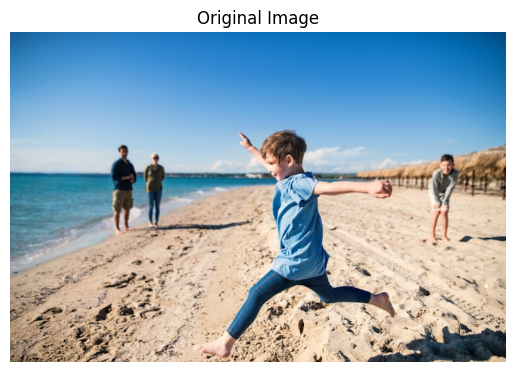

📝 Original Caption: a young boy on the beach playing with a frisbee
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 0.00%
max Linf perturbation: 0.00000, nan in tensor: 0, max: 1.00000, min: -1.00000
robust accuracy: 0.00%


<ipython-input-22-6f9bab6992c9>:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  adv_output_ids5 = model.generate(torch.tensor(adv_pixel_values5).to(device), max_length=16, num_beams=4)
<ipython-input-22-6f9bab6992c9>:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plt.imshow(torch.tensor(adv_pixel_values5).squeeze().permute(1, 2, 0).cpu().numpy())


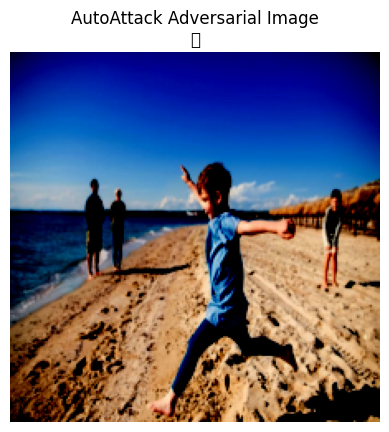

📝 Adversarial Caption: a young boy on the beach playing with a frisbee


In [22]:
# 📦 Install autoattack (if not already installed)
!pip install git+https://github.com/fra31/auto-attack

import torch
import matplotlib.pyplot as plt
from PIL import Image
from autoattack import AutoAttack
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model & processor
model = VisionEncoderDecoderModel.from_pretrained("nlpconnect/vit-gpt2-image-captioning").to(device)
feature_extractor = ViTImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
tokenizer = AutoTokenizer.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
model.eval()

# Load and preprocess the image
image_path5 = "/content/drive/MyDrive/5captionimage.jpeg"
image5 = Image.open(image_path5).convert("RGB")


# Show original
plt.imshow(image5)
plt.title("Original Image")
plt.axis("off")
plt.show()

# Get original caption
pixel_values5 = feature_extractor(images=image5, return_tensors="pt").pixel_values.to(device)
output_ids5 = model.generate(pixel_values5, max_length=16, num_beams=4)
caption5 = tokenizer.decode(output_ids5[0], skip_special_tokens=True).strip()
print("📝 Original Caption:", caption5)

# Use only ViT encoder for attack
vit_encoder = model.encoder
vit_encoder.eval()

# Create dummy classifier wrapper for AutoAttack
class ViTWrapper(torch.nn.Module):
    def __init__(self, vit):
        super().__init__()
        self.vit = vit

    def forward(self, x):
        # Use CLS token representation to simulate logits
        out = self.vit(x).last_hidden_state[:, 0, :]
        # Fake logits for 10 classes by projecting to 10 dims
        return torch.nn.Linear(out.shape[1], 10).to(device)(out)

# Initialize wrapped model
wrapped_model = ViTWrapper(vit_encoder).to(device)

# Run AutoAttack (one ε value, e.g. 0.1) , and specify 'cpu' device
autoattack = AutoAttack(wrapped_model, norm='Linf', eps=0.1, version='standard', device='cpu') # Specify device here
pixel_values_np = pixel_values.clone().detach().cpu().numpy()
labels = torch.zeros((1,), dtype=torch.long).to(device)  # dummy label


# Generate adversarial image
adv_pixel_values5 = autoattack.run_standard_evaluation(pixel_values5.cpu(), labels.cpu(), bs=1) # Inputs also need to be on CPU

# Pass adversarial image through full captioning model
with torch.no_grad():
    adv_output_ids5 = model.generate(torch.tensor(adv_pixel_values5).to(device), max_length=16, num_beams=4)
    adv_caption5 = tokenizer.decode(adv_output_ids5[0], skip_special_tokens=True).strip()

# Display
plt.imshow(torch.tensor(adv_pixel_values5).squeeze().permute(1, 2, 0).cpu().numpy())
plt.title(f"AutoAttack Adversarial Image\n📝")
plt.axis("off")
plt.show()

print("📝 Adversarial Caption:", adv_caption5)

# **for different epsilon values**

  Cloning https://github.com/fra31/auto-attack to /tmp/pip-req-build-v5_1snwo
  Running command git clone --filter=blob:none --quiet https://github.com/fra31/auto-attack /tmp/pip-req-build-v5_1snwo
  Resolved https://github.com/fra31/auto-attack to commit a39220048b3c9f2cca9a4d3a54604793c68eca7e
  Preparing metadata (setup.py) ... done


Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "architectures": [
    "ViTModel"
  ],
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "qkv_bias": true,
  "torch_dtype": "float32",
  "transformers_version": "4.50.3"
}

Config of the decoder: <class 'transformers.models.gpt2.modeling_gpt2.GPT2LMHeadModel'> is overwritten by shared decoder config: GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": true,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "decoder_start_to

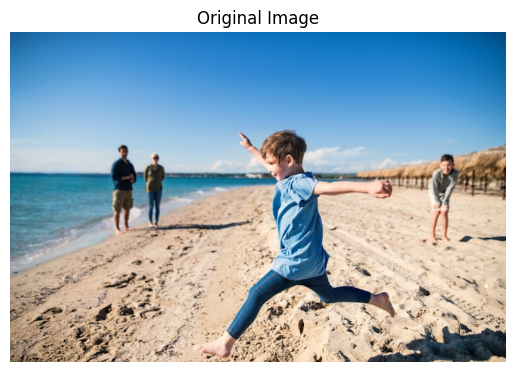

📝 Original Caption: a young boy on the beach playing with a frisbee

⚠️ Running AutoAttack for ε = 0.1...
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 0.00%
max Linf perturbation: 0.00000, nan in tensor: 0, max: 1.00000, min: -1.00000
robust accuracy: 0.00%


<ipython-input-29-0391a9af3f8a>:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  adv_output_ids = model.generate(torch.tensor(adv_pixel_values).to(device), max_length=16, num_beams=4)
<ipython-input-29-0391a9af3f8a>:74: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plt.imshow(torch.tensor(adv_pixel_values).squeeze().permute(1, 2, 0).cpu().numpy())
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


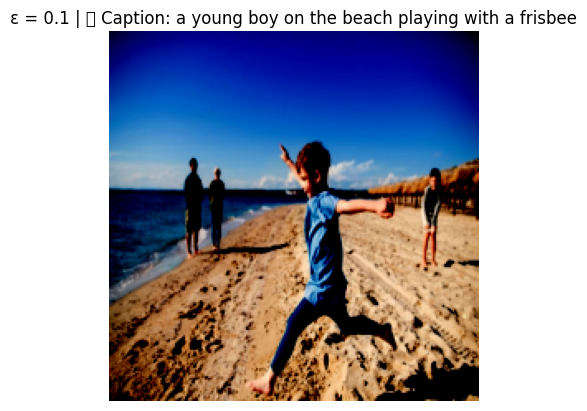

📝 Caption for ε = 0.1 ➜ a young boy on the beach playing with a frisbee

⚠️ Running AutoAttack for ε = 0.3...
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 0.00%
max Linf perturbation: 0.00000, nan in tensor: 0, max: 1.00000, min: -1.00000
robust accuracy: 0.00%


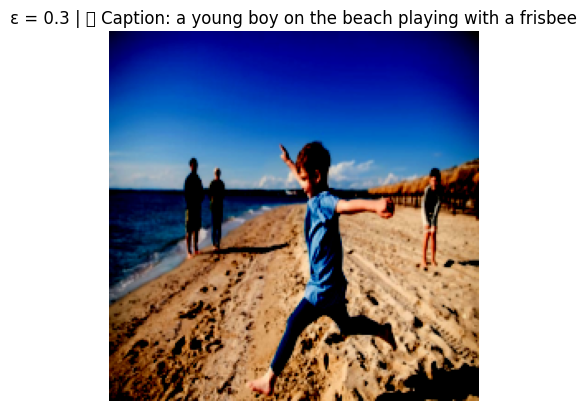

📝 Caption for ε = 0.3 ➜ a young boy on the beach playing with a frisbee

⚠️ Running AutoAttack for ε = 0.8...
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 0.00%
max Linf perturbation: 0.00000, nan in tensor: 0, max: 1.00000, min: -1.00000
robust accuracy: 0.00%


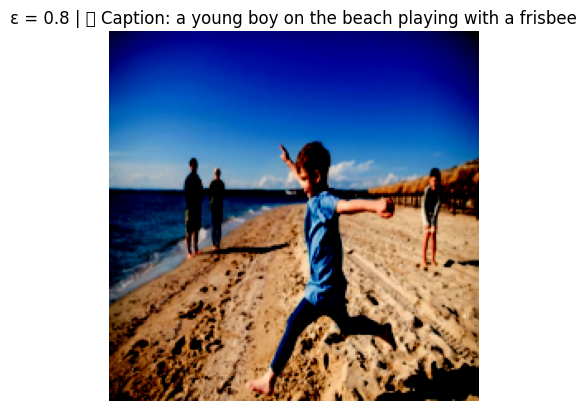

📝 Caption for ε = 0.8 ➜ a young boy on the beach playing with a frisbee

⚠️ Running AutoAttack for ε = 1.0...
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 0.00%
max Linf perturbation: 0.00000, nan in tensor: 0, max: 1.00000, min: -1.00000
robust accuracy: 0.00%


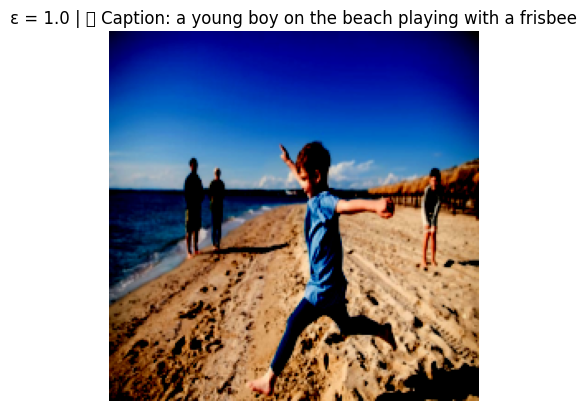

📝 Caption for ε = 1.0 ➜ a young boy on the beach playing with a frisbee

⚠️ Running AutoAttack for ε = 1.5...
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 0.00%
max Linf perturbation: 0.00000, nan in tensor: 0, max: 1.00000, min: -1.00000
robust accuracy: 0.00%


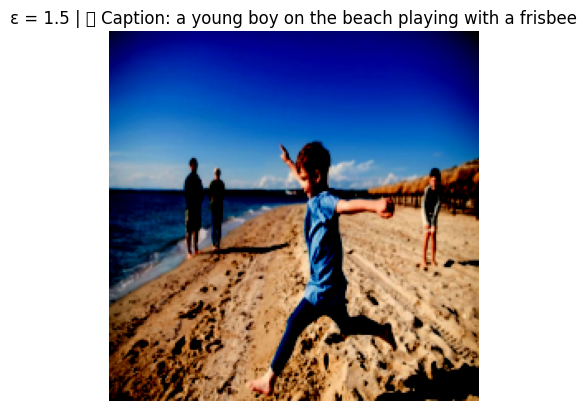

📝 Caption for ε = 1.5 ➜ a young boy on the beach playing with a frisbee


In [29]:
# 📦 Install autoattack (if not already installed)
!pip install git+https://github.com/fra31/auto-attack

import torch
import matplotlib.pyplot as plt
from PIL import Image
from autoattack import AutoAttack
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model & processor
model = VisionEncoderDecoderModel.from_pretrained("nlpconnect/vit-gpt2-image-captioning").to(device)
feature_extractor = ViTImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
tokenizer = AutoTokenizer.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
model.eval()

# Load and preprocess the image
image_path5 = "/content/drive/MyDrive/5captionimage.jpeg"
image5 = Image.open(image_path5).convert("RGB")

# Show original
plt.imshow(image5)
plt.title("Original Image")
plt.axis("off")
plt.show()

# Original caption
pixel_values5 = feature_extractor(images=image5, return_tensors="pt").pixel_values.to(device)
output_ids5 = model.generate(pixel_values5, max_length=16, num_beams=4)
caption5 = tokenizer.decode(output_ids5[0], skip_special_tokens=True).strip()
print("📝 Original Caption:", caption5)

# ViT Encoder for attack
vit_encoder = model.encoder
vit_encoder.eval()

# Dummy classifier wrapper
class ViTWrapper(torch.nn.Module):
    def __init__(self, vit):
        super().__init__()
        self.vit = vit

    def forward(self, x):
        out = self.vit(x).last_hidden_state[:, 0, :]
        return torch.nn.Linear(out.shape[1], 10).to(x.device)(out)

# Wrap model
wrapped_model = ViTWrapper(vit_encoder).to(device)

# Dummy label
labels = torch.zeros((1,), dtype=torch.long).to("cpu")  # AutoAttack requires labels

# Epsilon values to try
epsilons = [0.1, 0.3, 0.8, 1.0,1.5]

# Run attack for each epsilon
for eps in epsilons:
    print(f"\n⚠️ Running AutoAttack for ε = {eps}...")

    # Setup AutoAttack with specified epsilon
    autoattack = AutoAttack(wrapped_model, norm='Linf', eps=eps, version='standard', device='cpu')

    # Attack (must run on CPU)
    adv_pixel_values = autoattack.run_standard_evaluation(pixel_values5.cpu(), labels, bs=1)

    # Generate caption from attacked image
    with torch.no_grad():
        adv_output_ids = model.generate(torch.tensor(adv_pixel_values).to(device), max_length=16, num_beams=4)
        adv_caption = tokenizer.decode(adv_output_ids[0], skip_special_tokens=True).strip()

    # Display image
    plt.imshow(torch.tensor(adv_pixel_values).squeeze().permute(1, 2, 0).cpu().numpy())
    plt.title(f"ε = {eps} | 📝 Caption: {adv_caption}")
    plt.axis("off")
    plt.show()

    print(f"📝 Caption for ε = {eps} ➜ {adv_caption}")
